In [1]:
!python -V


Python 3.12.4


In [2]:
!pip install -r "/workspaces/mlops-zoomcamp/requirements.txt"

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import pickle

import mlflow

In [4]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [5]:
mlflow.set_experiment("nyc-taxi-experiment")

2024/08/11 15:56:16 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/workspaces/mlops-zoomcamp/notebooks/02-tracking_experiment/mlruns/1', creation_time=1723391776743, experiment_id='1', last_update_time=1723391776743, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [6]:
df = pd.read_parquet("../../data/green_tripdata_2021-01.parquet")

In [7]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)


In [8]:
#df = df[df.trip_type == 2]

In [9]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

In [10]:
df['duration'] = df['duration'].apply(lambda td: td.total_seconds() / 60)

In [11]:
df['duration']

0         3.933333
1         8.750000
2         5.966667
3         7.083333
4         0.066667
           ...    
76513    38.000000
76514    38.000000
76515    11.000000
76516    27.000000
76517    10.000000
Name: duration, Length: 76518, dtype: float64

/tmp/ipykernel_5062/2111361885.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['duration'])


<Axes: xlabel='duration', ylabel='Density'>

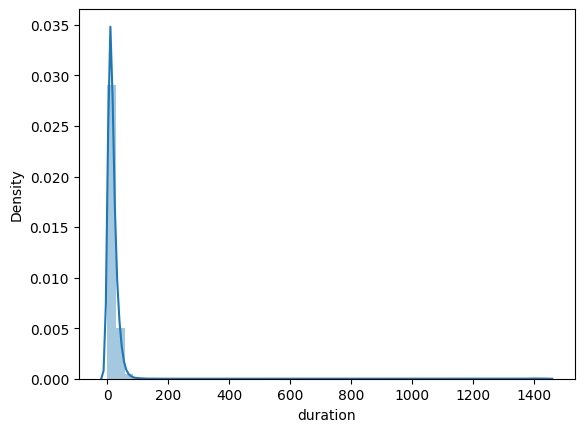

In [12]:
sns.distplot(df['duration'])

In [13]:
df['duration'].describe(percentiles=[0.95,0.98,0.99])

count    76518.000000
mean        19.927896
std         59.338594
min          0.000000
50%         13.883333
95%         44.000000
98%         56.000000
99%         67.158167
max       1439.600000
Name: duration, dtype: float64

In [14]:
((df['duration'] >= 1 ) & (df['duration'] <=60)).mean()

0.9658903787344154

In [15]:
((df['duration'] >= 0 ) & (df['duration'] <=1)).mean() 

0.019903813481795134

In [16]:
df = df[(df['duration'] >= 1 ) & (df['duration'] <=60)]

In [17]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.50,...,0.5,0.96,0.00,None,0.3,5.76,1.0,1.0,0.00,2.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [18]:
categorical = ['PULocationID', 'DOLocationID']

In [19]:
numerical = ['trip_distance']

In [20]:
df[categorical].dtypes

PULocationID    int64
DOLocationID    int64
dtype: object

In [21]:
df[categorical].astype(str).dtypes

PULocationID    object
DOLocationID    object
dtype: object

In [22]:
df[categorical] = df[categorical].astype(str)

In [23]:
df[categorical].dtypes

PULocationID    object
DOLocationID    object
dtype: object

In [24]:
dv = DictVectorizer()

In [25]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

In [26]:
train_dicts

[{'PULocationID': '43', 'DOLocationID': '151', 'trip_distance': 1.01},
 {'PULocationID': '166', 'DOLocationID': '239', 'trip_distance': 2.53},
 {'PULocationID': '41', 'DOLocationID': '42', 'trip_distance': 1.12},
 {'PULocationID': '168', 'DOLocationID': '75', 'trip_distance': 1.99},
 {'PULocationID': '75', 'DOLocationID': '75', 'trip_distance': 0.45},
 {'PULocationID': '225', 'DOLocationID': '265', 'trip_distance': 12.19},
 {'PULocationID': '244', 'DOLocationID': '244', 'trip_distance': 3.39},
 {'PULocationID': '75', 'DOLocationID': '213', 'trip_distance': 6.69},
 {'PULocationID': '74', 'DOLocationID': '238', 'trip_distance': 2.34},
 {'PULocationID': '74', 'DOLocationID': '60', 'trip_distance': 5.48},
 {'PULocationID': '42', 'DOLocationID': '41', 'trip_distance': 0.9},
 {'PULocationID': '74', 'DOLocationID': '116', 'trip_distance': 2.08},
 {'PULocationID': '116', 'DOLocationID': '143', 'trip_distance': 4.64},
 {'PULocationID': '75', 'DOLocationID': '42', 'trip_distance': 1.68},
 {'PULo

In [27]:
X_train = dv.fit_transform(train_dicts)

In [28]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=109',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=118',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',

In [29]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 221724 stored elements and shape (73908, 507)>

In [30]:
target = 'duration'

In [31]:
y_train = df[target].values

In [32]:
y_train

array([ 3.93333333,  8.75      ,  5.96666667, ..., 11.        ,
       27.        , 10.        ])

In [33]:
lr = LinearRegression()

In [34]:
lr.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = lr.predict(X_train)

/tmp/ipykernel_5062/1219225857.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label="prediction")
/tmp/ipykernel_5062/1219225857.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label="actual")


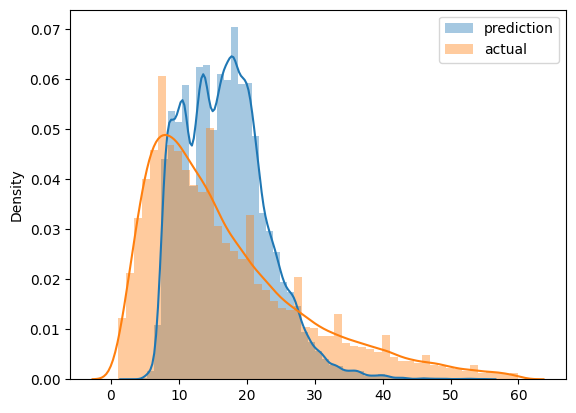

In [36]:
sns.distplot(y_pred, label="prediction")
sns.distplot(y_train, label="actual")

plt.legend()

In [37]:
mean_squared_error(y_train, y_pred, squared=False)

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


9.838799799829577

In [38]:
def read_dataframe(filename, categorical, numerical):
    df = pd.read_parquet(filename)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df['duration'] = df['duration'].apply(lambda td: td.total_seconds() / 60)
    df = df[(df['duration'] >= 1 ) & (df['duration'] <=60)]
    df[categorical] = df[categorical].astype(str)

    return df

In [39]:
df_train = read_dataframe("../../data/green_tripdata_2021-01.parquet", categorical, numerical)

In [40]:
df_val = read_dataframe("../../data/green_tripdata_2021-02.parquet", categorical, numerical)

In [41]:
df_train

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.50,...,0.5,0.96,0.00,None,0.3,5.76,1.0,1.0,0.00,2.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [42]:
df_val

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-02-01 00:34:03,2021-02-01 00:51:58,N,1.0,130,205,5.0,3.66,14.00,...,0.5,10.00,0.0,None,0.3,25.30,1.0,1.0,0.00,17.916667
1,2,2021-02-01 00:04:00,2021-02-01 00:10:30,N,1.0,152,244,1.0,1.10,6.50,...,0.5,0.00,0.0,None,0.3,7.80,2.0,1.0,0.00,6.500000
2,2,2021-02-01 00:18:51,2021-02-01 00:34:06,N,1.0,152,48,1.0,4.93,16.50,...,0.5,0.00,0.0,None,0.3,20.55,2.0,1.0,2.75,15.250000
3,2,2021-02-01 00:53:27,2021-02-01 01:11:41,N,1.0,152,241,1.0,6.70,21.00,...,0.5,0.00,0.0,None,0.3,22.30,2.0,1.0,0.00,18.233333
4,2,2021-02-01 00:57:46,2021-02-01 01:06:44,N,1.0,75,42,1.0,1.89,8.50,...,0.5,2.45,0.0,None,0.3,12.25,1.0,1.0,0.00,8.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64567,2,2021-02-28 22:19:00,2021-02-28 22:29:00,None,NaN,129,7,NaN,2.63,10.04,...,0.0,0.00,0.0,None,0.3,10.34,NaN,NaN,NaN,10.000000
64568,2,2021-02-28 23:18:00,2021-02-28 23:27:00,None,NaN,116,166,NaN,1.87,8.33,...,0.0,1.89,0.0,None,0.3,10.52,NaN,NaN,NaN,9.000000
64569,2,2021-02-28 23:44:00,2021-02-28 23:58:00,None,NaN,74,151,NaN,2.40,12.61,...,0.0,0.00,0.0,None,0.3,12.91,NaN,NaN,NaN,14.000000
64570,2,2021-02-28 23:07:00,2021-02-28 23:14:00,None,NaN,42,42,NaN,1.11,11.95,...,0.0,0.00,0.0,None,0.3,15.00,NaN,NaN,NaN,7.000000


In [43]:
dv = DictVectorizer()
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
y_val = df_val[target].values

In [44]:
with mlflow.start_run():
    alpha = 0.1
    mlflow.set_tag("developer", "magda")
    mlflow.log_param("train_data", "green_tripdata_2021-01")
    mlflow.log_param("val_data", "green_tripdata_2021-02")
    mlflow.log_param("alpha", alpha)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    train_mse = mean_squared_error(y_train, y_train_pred, squared=False)
    val_mse = mean_squared_error(y_val, y_val_pred, squared=False)
    print("train mse: ", train_mse)
    print("val mse: ", val_mse)
    mlflow.log_metric("train_mse", train_mse)
    mlflow.log_metric("val_mse", val_mse)


train mse:  9.838799799829577
val mse:  10.499110712717727


/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBOOST

In [45]:
import xgboost as xgb

In [46]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [47]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [53]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred=booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)
    return {"loss": rmse, 'status': STATUS_OK}

In [54]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

In [55]:
best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [16:05:53] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:9.71212                           
[1]	validation-rmse:8.22779                           
[2]	validation-rmse:7.39442                           
[3]	validation-rmse:6.93567                           
[4]	validation-rmse:6.69473                           
[5]	validation-rmse:6.56925                           
[6]	validation-rmse:6.51085                           
[7]	validation-rmse:6.48179                           
[8]	validation-rmse:6.46593                           
[9]	validation-rmse:6.46239                           
[10]	validation-rmse:6.46208                          
[11]	validation-rmse:6.46576                          
[12]	validation-rmse:6.46945                          
[13]	validation-rmse:6.47638                          
[14]	validation-rmse:6.48094                          
[15]	validation-rmse:6.48444                          
[16]	validation-rmse:6.49065                          
[17]	validation-rmse:6.49626                          
[18]	valid

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [16:06:18] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:8.55378                                                    
[1]	validation-rmse:7.18227                                                    
[2]	validation-rmse:6.72307                                                    
[3]	validation-rmse:6.57216                                                    
[4]	validation-rmse:6.53031                                                    
[5]	validation-rmse:6.50673                                                    
[6]	validation-rmse:6.49614                                                    
[7]	validation-rmse:6.49612                                                    
[8]	validation-rmse:6.50074                                                    
[9]	validation-rmse:6.50259                                                    
[10]	validation-rmse:6.50914                                                   
[11]	validation-rmse:6.50996                                                   
[12]	validation-rmse:6.51435            

...

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [16:18:06] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[3]	validation-rmse:6.57430                                                     
[4]	validation-rmse:6.53871                                                     
[5]	validation-rmse:6.52721                                                     
[6]	validation-rmse:6.51223                                                     
[7]	validation-rmse:6.50664                                                     
[8]	validation-rmse:6.50484                                                     
[9]	validation-rmse:6.50703                                                     
[10]	validation-rmse:6.50813                                                    
[11]	validation-rmse:6.51737                                                    
[12]	validation-rmse:6.51796                                                    
[13]	validation-rmse:6.53643                                                    
[14]	validation-rmse:6.53766                                                    
[15]	validation-rmse:6.53973

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [16:18:09] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:11.53034                                                    
[1]	validation-rmse:10.91851                                                    
[2]	validation-rmse:10.37207                                                    
[3]	validation-rmse:9.88447                                                     
[4]	validation-rmse:9.45155                                                     
[5]	validation-rmse:9.06644                                                     
[6]	validation-rmse:8.72664                                                     
[7]	validation-rmse:8.42609                                                     
[8]	validation-rmse:8.16191                                                     
[9]	validation-rmse:7.92916                                                     
[10]	validation-rmse:7.72460                                                    
[11]	validation-rmse:7.54524                                                    
[12]	validation-rmse:7.38793

/home/codespace/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



In [66]:
model = Lasso()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  11.562050466293025
val mse:  12.212583224318818


In [67]:
model = Lasso(alpha = 0.0001)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  9.776228723456013
val mse:  10.47054920225702


In [68]:
model = Lasso(alpha = 0.1)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  11.059006857960965
val mse:  11.674811916671658


In [70]:
model = Ridge()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  9.803663492778094
val mse:  10.47817109594213


In [72]:
model = Ridge(alpha = 0.0001)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  9.799224161307277
val mse:  10.476414581021322


In [73]:
df_train['PU_DO'] = df_train['PULocationID'] + "_" + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + "_" + df_val['DOLocationID']

In [75]:
categorical = ['PU_DO']

In [77]:
dv = DictVectorizer()
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
y_val = df_val[target].values

In [78]:
X_train

<73908x13221 sparse matrix of type '<class 'numpy.float64'>'
	with 147816 stored elements in Compressed Sparse Row format>

In [79]:
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))


train mse:  5.699564118198951
val mse:  7.758715207820828


In [80]:
model = Ridge(alpha = 0.0001)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("train mse: ", mean_squared_error(y_train, y_train_pred, squared=False))
print("val mse: ", mean_squared_error(y_val, y_val_pred, squared=False))

train mse:  4.944349964622713
val mse:  7.512309386686627


In [85]:
with open("models\ridge.bin", "wb") as f_out:
    pickle.dump((dv, model), f_out)